# 第 2 讲：反馈是什么——从 P、PD 到完整状态反馈

第 1 讲看到：自行车只要稍微倾斜，滚转角就会指数增长。本讲开始回答最核心的问题：如何根据测量到的倾斜，主动转动车把阻止它倒下。

本讲目标：

1. 理解负反馈不是简单地“方向取负”，而是让误差趋近零；
2. 理解 P、D 和转向回正项分别在做什么；
3. 看见只控制滚转而不约束车把会产生什么问题；
4. 第一次使用 50 Hz 的采样控制和控制量饱和。

In [6]:
import math
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})

def bicycle_matrices(speed):
    a, b, h, m, g = 0.117, 0.271, 0.292, 5.0, 9.81
    Ib = 4.0 / 3.0 * m * h**2
    a1 = m * a * h * speed / (b * Ib)
    a2 = m * speed**2 * h / (b * Ib)
    a4 = m * g * h / Ib
    A = np.array([[0.0, 0.0, 0.0],
                  [0.0, 0.0, 1.0],
                  [a2,  a4,  0.0]])
    B = np.array([[1.0], [0.0], [a1]])
    return A, B

A, B = bicycle_matrices(2.0)


## 1. 反馈的基本结构

反馈控制器不断重复四步：

1. 测量当前状态；
2. 与目标状态比较；
3. 根据误差计算控制量；
4. 把控制量作用到系统，再测量新的状态。

当目标是直立、车把回正时，$x_r=0$。最一般的线性状态反馈是

$$u=K(x_r-x)=-Kx$$

这里 $K=[k_\delta, k_\phi, k_{\dot\phi}]$。每个增益把一个状态转换成转向角速度的一部分。真正的正负方向由坐标定义和模型共同决定，所以不能脱离方程只背“向左倒就向左打把”。

## 2. P、D 和车把回正项

如果暂时只看滚转：

$$u=-k_\phi\phi-k_{\dot\phi}\dot\phi$$

- $k_\phi\phi$ 类似 P：倾斜越大，修正越强；
- $k_{\dot\phi}\dot\phi$ 类似 D：如果正在快速倒下，提前制动，增加阻尼；
- $k_\delta\delta$ 让转向角最终回到零。

第三项很容易被初学者忽略。没有它，控制器可能暂时稳住滚转，却让车把不断偏向一侧。因为 $\delta$ 本身是 $u$ 的积分，未约束的积分状态会漂移。

In [7]:
controllers = {
    "开环": np.array([0.0, 0.0, 0.0]),
    "只有滚转 PD": np.array([0.0, 8.0, 1.5]),
    "PD + 转向回正": np.array([5.0, 8.0, 1.5]),
    "经验整定的完整反馈": np.array([10.0, 10.0, 2.0]),
}

for name, K in controllers.items():
    poles = np.linalg.eigvals(A - B @ K.reshape(1, 3))
    stable = np.all(np.real(poles) < 0)
    print(f"{name:16s} poles={poles}, stable={stable}")


开环               poles=[ 5.0197 -5.0197  0.    ], stable=False
只有滚转 PD          poles=[ 0.9141+7.6158j  0.9141-7.6158j -5.1548+0.j    ], stable=False
PD + 转向回正        poles=[-5.3097+0.j     -1.5085+5.5783j -1.5085-5.5783j], stable=True
经验整定的完整反馈        poles=[-4.864 +1.8302j -4.864 -1.8302j -4.7077+0.j    ], stable=True


## 3. 连续物体、离散控制器

真实车身一直在运动，但微控制器只能每隔一段时间读取传感器并更新指令。教程设控制周期为 $T_s=0.02$ s，也就是 50 Hz。两个更新时刻之间，控制指令保持不变，这叫**零阶保持**。

下面用 1 ms 积分步长模拟连续车身，却只每 20 ms 更新一次控制。还要加入 $|u|\le 10$ rad/s 的限幅，因为执行器不可能无限快。

In [8]:
def simulate_sampled_feedback(A, B, K, x0, duration=2.0,
                              plant_dt=0.001, control_dt=0.02,
                              control_limit=10.0):
    time = np.arange(0.0, duration + plant_dt, plant_dt)
    states = np.zeros((time.size, 3))
    controls = np.zeros(time.size)
    states[0] = x0
    update_every = int(round(control_dt / plant_dt))
    held_control = 0.0

    for k in range(time.size - 1):
        if k % update_every == 0:
            held_control = float(-K @ states[k])
            held_control = float(np.clip(held_control, -control_limit, control_limit))
        controls[k] = held_control
        states[k + 1] = states[k] + (A @ states[k] + B[:, 0] * held_control) * plant_dt
    controls[-1] = held_control
    return time, states, controls


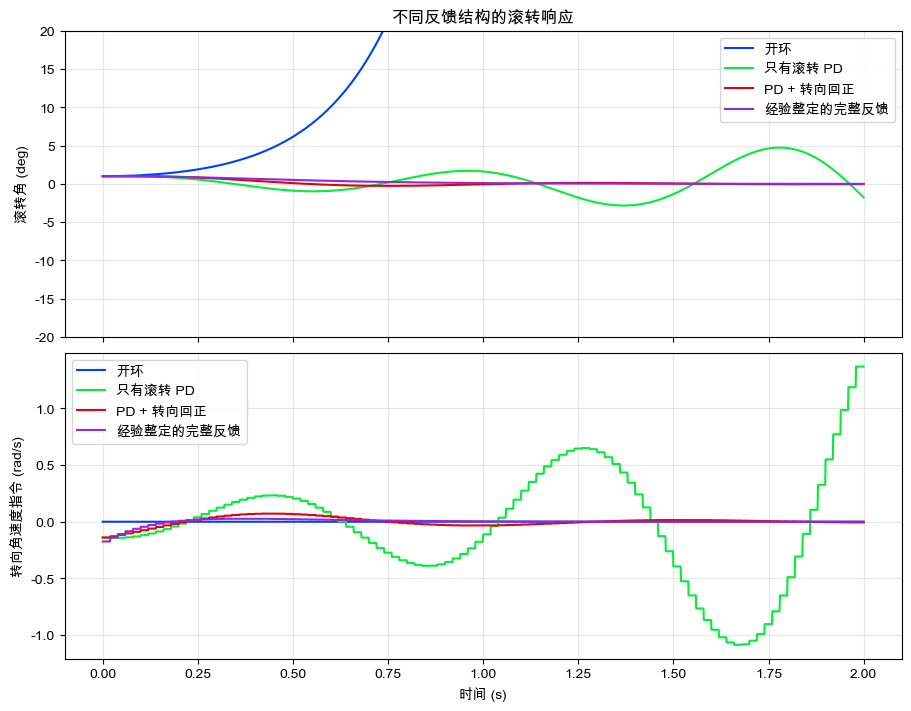

In [9]:
x0 = np.deg2rad([0.0, 1.0, 0.0])
results = {}
for name, K in controllers.items():
    results[name] = simulate_sampled_feedback(A, B, K, x0)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
for name, (time, states, controls) in results.items():
    axes[0].plot(time, np.rad2deg(states[:, 1]), label=name)
    axes[1].plot(time, controls, label=name)
axes[0].set_ylabel("滚转角 (deg)")
axes[0].set_ylim(-20, 20)
axes[0].set_title("不同反馈结构的滚转响应")
axes[1].set_ylabel("转向角速度指令 (rad/s)")
axes[1].set_xlabel("时间 (s)")
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()
plt.show()


从图和特征值可以得到三条重要结论：

1. 开环发散；
2. 只有滚转 PD 不一定稳定，因为转向角这个积分状态没有被约束；
3. 加入转向回正后，三个闭环模态才可能全部进入左半平面。

因此，这里的控制器虽然在物理直觉上像“滚转 PD”，数学上却是一个三状态反馈控制器。

## 4. D 项为什么怕噪声

如果滚转角速度不是陀螺仪直接测得，而是用相邻角度相减得到：

$$\dot\phi[k]\approx\frac{\phi[k]-\phi[k-1]}{T_s}$$

那么测量噪声也会被除以很小的 $T_s$，从而显著放大。工程上通常优先使用陀螺仪角速度，或对差分结果低通滤波。不要把增大 D 增益当成免费的阻尼。

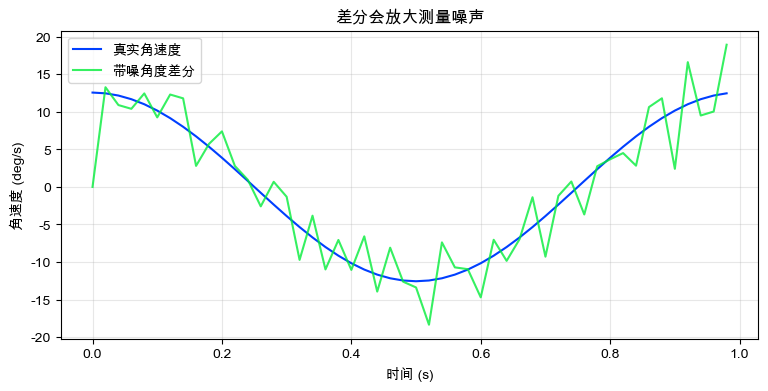

In [10]:
rng = np.random.default_rng(7)
sample_time = np.arange(0, 1.0, 0.02)
true_angle = np.deg2rad(2.0 * np.sin(2 * np.pi * sample_time))
measured_angle = true_angle + np.deg2rad(rng.normal(0.0, 0.05, sample_time.size))
difference_rate = np.r_[0.0, np.diff(measured_angle) / 0.02]
true_rate = np.deg2rad(4.0 * np.pi * np.cos(2 * np.pi * sample_time))

plt.figure(figsize=(9, 4))
plt.plot(sample_time, np.rad2deg(true_rate), label="真实角速度")
plt.plot(sample_time, np.rad2deg(difference_rate), label="带噪角度差分", alpha=0.8)
plt.xlabel("时间 (s)")
plt.ylabel("角速度 (deg/s)")
plt.title("差分会放大测量噪声")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 练习

1. 固定其他增益，只改变 `k_phi`，记录最大滚转角和最大控制量。
2. 把 `k_roll_rate` 设为 0，观察阻尼消失后的振荡。
3. 把控制频率从 50 Hz 改成 10 Hz。即使连续时间特征值没有变化，采样仿真是否仍稳定？
4. 把控制限幅从 10 rad/s 改成 0.5 rad/s，再逐渐增大初始倾角。找出控制器能够恢复的近似边界。
5. 思考：手工试增益虽然能成功，但如何系统地选择三个增益？第 3 讲将用极点配置回答。